## Introduction:
### This analysis was conducted on a Bank churn Dataset, downloaded in CSV format from Kaggle, to gain a comprehensive understanding of customer behavior within the bank. The study aims to examine both the total number of customers and the rate at which customers leave the bank (churn). By analyzing this dataset, the project seeks to identify key factors contributing to customer churn, such as regions with the highest churn rates and specific age groups that are dissatisfied with the bank’s services. The insights derived from this analysis can help the bank address these issues and improve customer retention.


In [72]:
import pandas as pd

In [73]:
df = pd.read_csv('churned bank analysis.csv')
print(df)

      CustomerId    Surname  CreditScore Geography  Gender  Age     AgeGroup  \
0       15634602   Hargrave          619    France  Female   42  Middle- Age   
1       15647311       Hill          608     Spain  Female   41  Middle- Age   
2       15619304       Onio          502    France  Female   42  Middle- Age   
3       15701354       Boni          699    France  Female   39  Middle- Age   
4       15737888   Mitchell          850     Spain  Female   43  Middle- Age   
...          ...        ...          ...       ...     ...  ...          ...   
9995    15606229   Obijiaku          771    France    Male   39  Middle- Age   
9996    15569892  Johnstone          516    France    Male   35  Middle- Age   
9997    15584532        Liu          709    France  Female   36  Middle- Age   
9998    15682355  Sabbatini          772   Germany    Male   42  Middle- Age   
9999    15628319     Walker          792    France  Female   28        Young   

      Tenure    Balance  NumOfProducts 

In [74]:
df.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [75]:
df.shape

(10000, 19)

In [76]:
df['CustomerId'].value_counts()

CustomerId
15656710    1
15768163    1
15672754    1
15719276    1
15692664    1
           ..
15737888    1
15701354    1
15619304    1
15647311    1
15634602    1
Name: count, Length: 10000, dtype: int64

“The analysis shows that the bank has a total of 10,000 customers. Further analysis will identify the number of customers who have churned and those who remain active. Active customers are those who continue to use the bank’s services, while churned customers are those who have left the bank due to poor service or other related factors.”

In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerId          10000 non-null  int64  
 1   Surname             10000 non-null  object 
 2   CreditScore         10000 non-null  int64  
 3   Geography           10000 non-null  object 
 4   Gender              10000 non-null  object 
 5   Age                 10000 non-null  int64  
 6   AgeGroup            10000 non-null  object 
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Complaining         10000 non-null  object 
 16  Satis

In [78]:
summary = df['Exited'].value_counts().to_frame(name='Customers')
summary.index = ['Retained','Churned']
print(summary)

          Customers
Retained       7962
Churned        2038


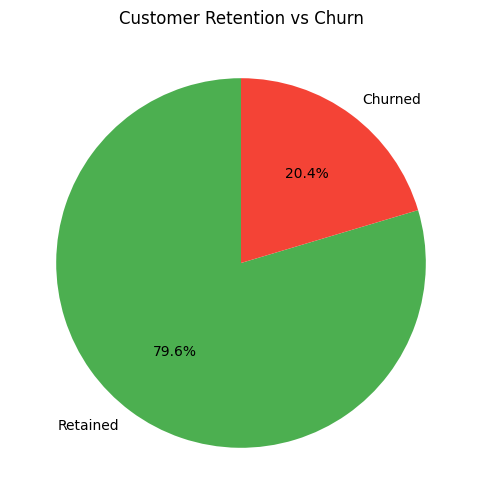

In [79]:
import matplotlib.pyplot as plt

# Customer counts
customer_counts = {'Retained': 7962, 'Churned': 2038}

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(customer_counts.values(), 
        labels=customer_counts.keys(), 
        autopct='%1.1f%%', 
        colors=['#4CAF50','#F44336'], 
        startangle=90)
plt.title('Customer Retention vs Churn')
plt.show()

The analysis reveals that out of the total customer base, 7,962 customers continue to use the bank’s services, while 2,038 customers have left the bank. This aligns with the key performance indicators (KPIs), which report 7,962 retained customers and 2,038 churned customers.

In [102]:
df['AgeGroup'].value_counts().reset_index()

,AgeGroup,count
0,Middle- Age,4926
1,Young,3679
2,Old,1244
3,Very old,151


TThe analysis of customer age groups indicates that there are 4,926 middle-aged customers, 3,679 young customers, 1,244 older customers, and 151 very old customers. The next step is to determine which age group contributes most to account dormancy in the bank, identifying the segment that drives the highest rate of inactive or dormant accounts.

In [105]:
df['Gender'].value_counts().reset_index()

,Gender,count
0,Male,5457
1,Female,4543


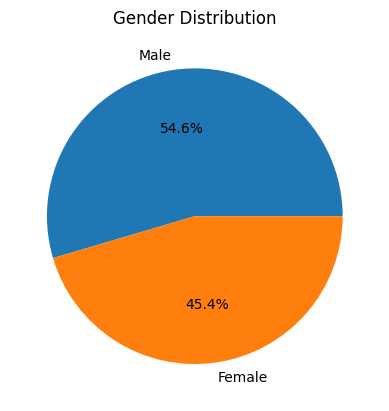

In [82]:
import matplotlib.pyplot as plt

# Assuming your data is in a Series like:
# gender_counts = df['Gender'].value_counts()

gender_counts = {'Male': 5457, 'Female': 4543}

plt.figure()
plt.pie(gender_counts.values(), labels=gender_counts.keys(), autopct='%1.1f%%')
plt.title('Gender Distribution')

plt.show()

Interpretation of the Data
Male: 5,457 (≈ 54.6%)
Female: 4,543 (≈ 45.4%)

This shows a slight male dominance in the dataset. The difference is not extreme, but it indicates that males are more represented by about 914 individuals.

In [83]:
churn_rate = df['Exited'].mean() * 100
print(churn_rate)

20.380000000000003


Meaning about 20% of customers left the bank.

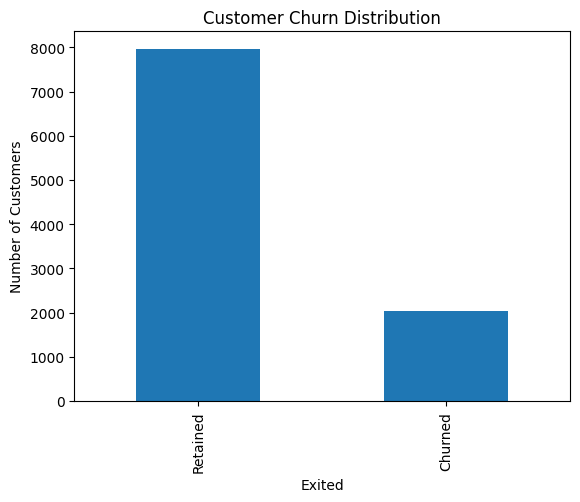

In [84]:
import matplotlib.pyplot as plt

df['Exited'].value_counts().plot(kind='bar')
plt.xticks([0,1], ['Retained','Churned'])
plt.title('Customer Churn Distribution')
plt.ylabel('Number of Customers')
plt.show()

Which Country Has the Highest Customer Churn?

Banks want to know where customers are leaving the most.

In [85]:
pd.crosstab(df['Geography'], df['Exited'])

Exited,0,1
Geography,,
France,4203,811
Germany,1695,814
Spain,2064,413


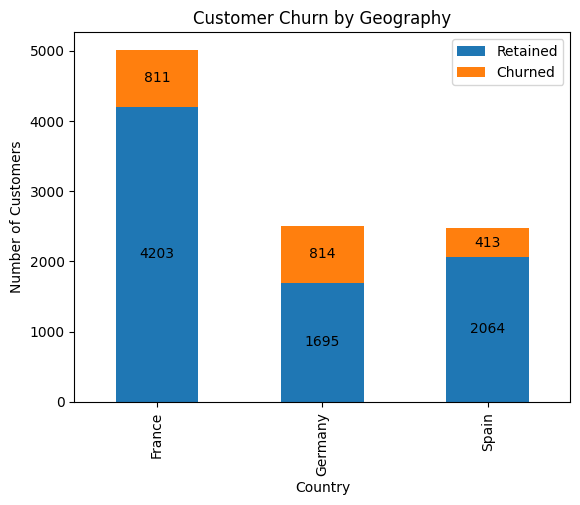

In [86]:
import pandas as pd
import matplotlib.pyplot as plt

# Create dataframe from your result
data = {
    'Retained': [4203, 1695, 2064],
    'Churned': [811, 814, 413]
}

geo_churn = pd.DataFrame(data, index=['France', 'Germany', 'Spain'])

# Plot
ax = geo_churn.plot(kind='bar', stacked=True)

# Add numbers to bars
for container in ax.containers:
    ax.bar_label(container, label_type='center')

plt.title('Customer Churn by Geography')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.legend(['Retained', 'Churned'])

plt.show()

Germany shows the highest churn level, with nearly half as many churned customers as retained ones

In [87]:
df.groupby('Geography')['Exited'].mean() * 100

Geography
France     16.174711
Germany    32.443204
Spain      16.673395
Name: Exited, dtype: float64

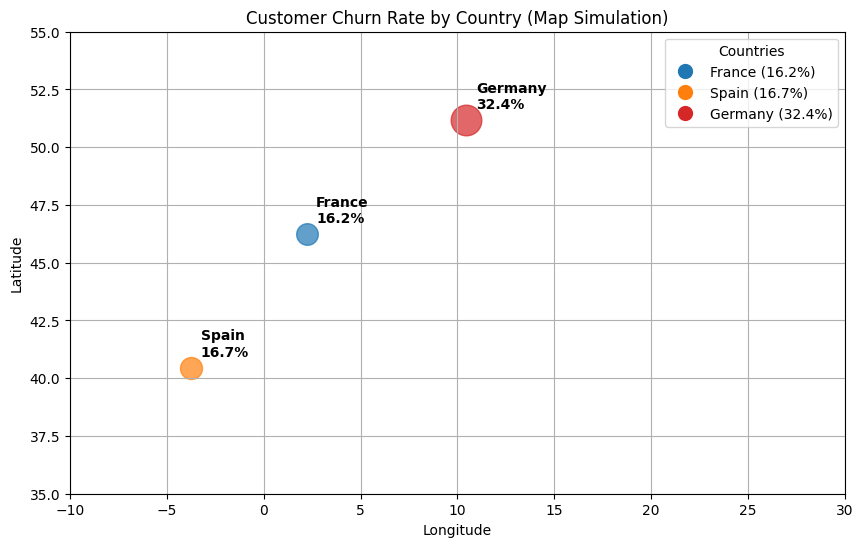

In [88]:
import matplotlib.pyplot as plt

# Country coordinates (latitude, longitude)
country_coords = {
    'France': (46.2276, 2.2137),
    'Spain': (40.4637, -3.7492),
    'Germany': (51.1657, 10.4515)
}

# Churn rates
churn_rate = {
    'France': 16.17,
    'Germany': 32.44,
    'Spain': 16.67
}

# Colors for each country
colors = {
    'France': '#1f77b4',   # blue
    'Spain': '#ff7f0e',    # orange
    'Germany': '#d62728'   # red
}

# Create figure
plt.figure(figsize=(10,6))
plt.xlim(-10, 30)  # Longitude range for Europe
plt.ylim(35, 55)   # Latitude range for Europe
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Customer Churn Rate by Country (Map Simulation)')

# Plot each country with color, size proportional to churn, and label
for country, (lat, lon) in country_coords.items():
    plt.scatter(lon, lat, 
                s=churn_rate[country]*15,  # size proportional to churn
                color=colors[country],
                alpha=0.7)
    plt.text(lon+0.5, lat+0.5, f"{country}\n{churn_rate[country]:.1f}%", fontsize=10, fontweight='bold')

# Create custom legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label=f"{country} ({churn_rate[country]:.1f}%)",
                          markerfacecolor=colors[country], markersize=12) for country in country_coords]
plt.legend(handles=legend_elements, title="Countries")

plt.grid(True)
plt.show()

Customer churn varies significantly by geography. Germany shows the highest churn level, with nearly half as many churned customers as retained ones. France and Spain show relatively lower churn rates. This suggests regional differences in customer satisfaction or competitive banking options.

2. Does Age Affect Customer Churn?

Older customers often behave differently from younger customers.

In [89]:
pd.crosstab(df['AgeGroup'], df['Exited'])

Exited,0,1
AgeGroup,,
Middle- Age,3812,1114
Old,625,619
Very old,136,15
Young,3389,290


In [106]:
age_churn_rate = df.groupby('AgeGroup')['Exited'].mean()*100
print(age_churn_rate.reset_index())

      AgeGroup     Exited
0  Middle- Age  22.614698
1          Old  49.758842
2     Very old   9.933775
3        Young   7.882577


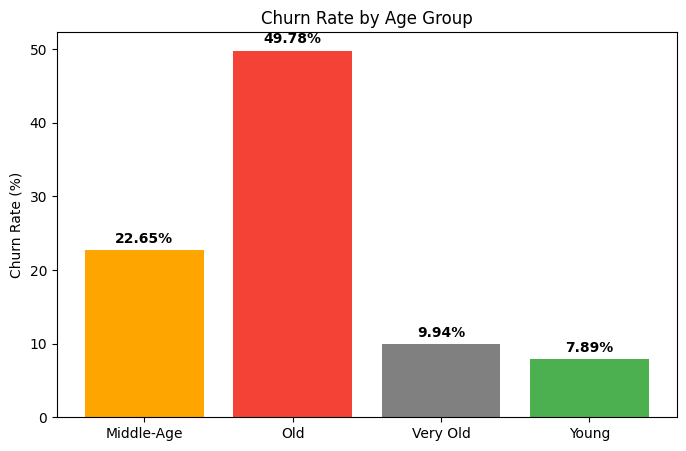

In [91]:
import matplotlib.pyplot as plt

age_groups = ['Middle-Age', 'Old', 'Very Old', 'Young']
churn_rate = [22.65, 49.78, 9.94, 7.89]

plt.figure(figsize=(8,5))
plt.bar(age_groups, churn_rate, color=['#FFA500','#F44336','#808080','#4CAF50'])
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Age Group')
for i, v in enumerate(churn_rate):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

Interpretation

Older customers might be switching banks more frequently. Churn behavior varies significantly across age groups. Customers classified as “Old” show the highest churn rate at nearly 50%, indicating a high risk of customer loss in this segment. Younger customers display stronger retention levels. The bank may need targeted engagement strategies for older clients to reduce churn.

3. Are Customers With Complaints More Likely to Churn?

This is very important for banks.

In [92]:
pd.crosstab(df['Complaining'], df['Exited'])

Exited,0,1
Complaining,,
No,7952,4
Yes,10,2034


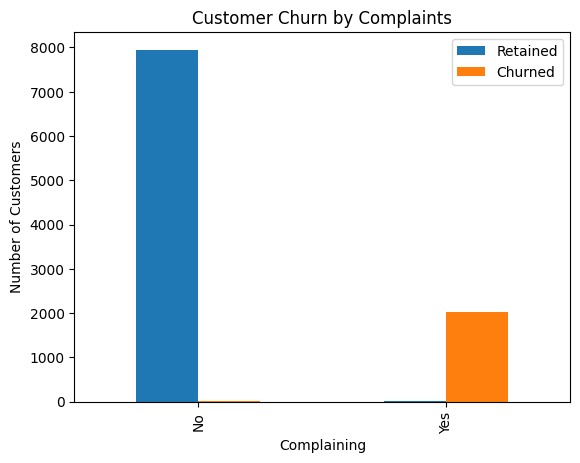

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

complain_churn = pd.crosstab(df['Complaining'], df['Exited'])

complain_churn.plot(kind='bar')

plt.title('Customer Churn by Complaints')
plt.xlabel('Complaining')
plt.ylabel('Number of Customers')
plt.legend(['Retained','Churned'])
plt.show()

Key Insight (Very Important)

Dataset shows an extreme relationship between complaints and churn:

Customers who complained almost always left the bank

Customers who did not complain almost always stayed

Business Interpretation

Complaints appear to be the strongest predictor of churn. This suggests that customer service and complaint resolution are critical factors affecting customer retention.

The analysis reveals a strong relationship between customer complaints and churn behavior. Nearly all customers who lodged complaints eventually exited the bank, while those who did not complain remained loyal. This indicates that unresolved complaints may be a major driver of customer churn and highlights the need for improved complaint management systems.

In [94]:
df.groupby('Complaining')['Exited'].mean() * 100

Complaining
No      0.050277
Yes    99.510763
Name: Exited, dtype: float64

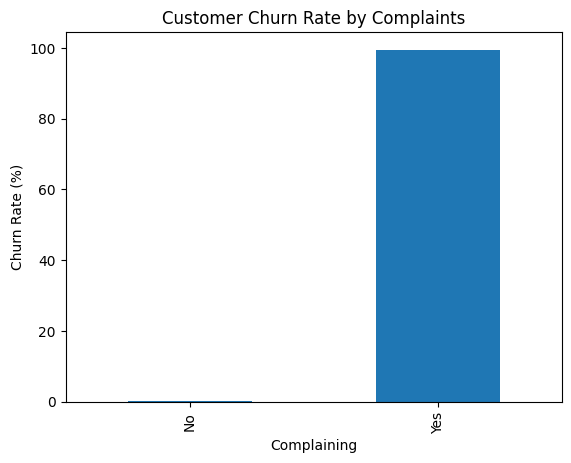

In [95]:
import matplotlib.pyplot as plt

complain_rate = df.groupby('Complaining')['Exited'].mean()*100

complain_rate.plot(kind='bar')

plt.title('Customer Churn Rate by Complaints')
plt.xlabel('Complaining')
plt.ylabel('Churn Rate (%)')
plt.show()

Interpretation

Customers who complain are far more likely to leave. Complaint behavior strongly predicts customer churn. Customers who filed complaints had a churn rate of approximately 99.5%, while customers who did not complain had almost zero churn. This indicates that unresolved complaints may be a critical driver of customer attrition. Improving complaint resolution processes could significantly reduce churn.

4. Does Balance Affect Churn?

Banks want to know if high-value customers are leaving.

In [96]:
df.groupby('Exited')['Balance'].mean()

Exited
0    72742.750663
1    91109.476006
Name: Balance, dtype: float64

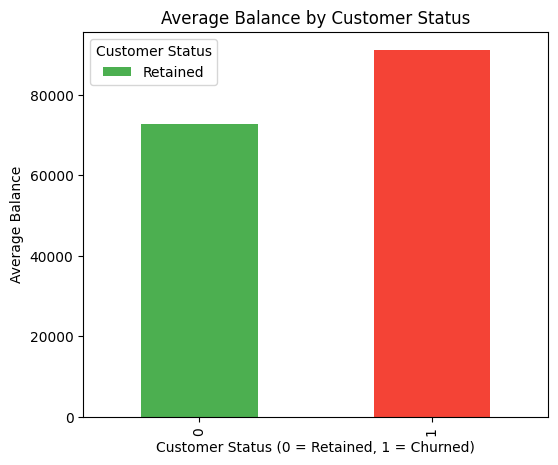

In [97]:
import matplotlib.pyplot as plt

# Compute average balance by customer status
balance_churn = df.groupby('Exited')['Balance'].mean()

# Define colors for bars
colors = ['#4CAF50', '#F44336']  # Green for Retained, Red for Churned

# Plot
ax = balance_churn.plot(kind='bar', color=colors, figsize=(6,5))

# Title and labels
plt.title('Average Balance by Customer Status')
plt.xlabel('Customer Status (0 = Retained, 1 = Churned)')
plt.ylabel('Average Balance')

# Add legend
plt.legend(['Retained', 'Churned'], title='Customer Status')

# Show plot
plt.show()

interpretation

High-balance customers may be leaving, which is dangerous for the bank's revenue.Since customers with higher balances are more likely to churn, the bank should prioritize retention strategies for high-value clients. Personalized relationship management and loyalty programs could help reduce the loss of these profitable customers.

5. Does Being an Active Member Reduce Churn?

In [98]:
pd.crosstab(df['IsActiveMember'], df['Exited'])

Exited,0,1
IsActiveMember,,
0,3546,1303
1,4416,735


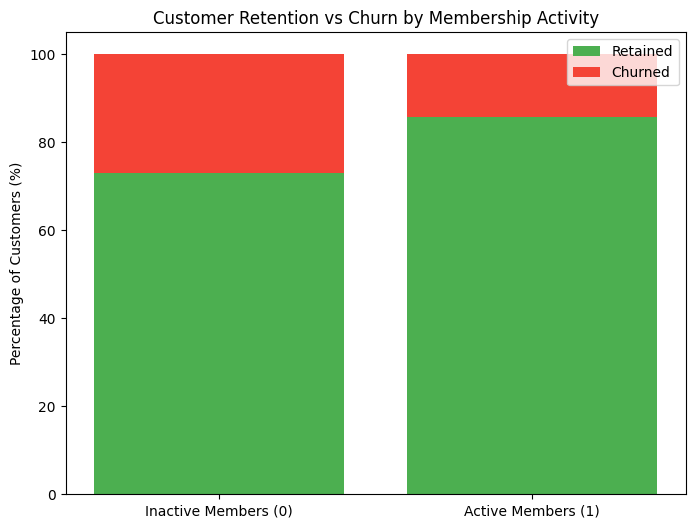

In [99]:
import matplotlib.pyplot as plt
import numpy as np

# Data
labels = ['Inactive Members (0)', 'Active Members (1)']
retained = np.array([3546, 4416])
churned = np.array([1303, 735])

# Calculate total for percentage
totals = retained + churned
retained_pct = retained / totals * 100
churned_pct = churned / totals * 100

# Plot
fig, ax = plt.subplots(figsize=(8,6))
ax.bar(labels, retained_pct, label='Retained', color='#4CAF50')
ax.bar(labels, churned_pct, bottom=retained_pct, label='Churned', color='#F44336')

# Labels and title
ax.set_ylabel('Percentage of Customers (%)')
ax.set_title('Customer Retention vs Churn by Membership Activity')
ax.legend()
plt.show()

We can interpret it as:

Inactive members (IsActiveMember = 0): 1,303 out of 4,849 have churned → higher churn rate.

Active members (IsActiveMember = 1): 735 out of 5,151 have churned → lower churn rate.

This clearly shows that customers who are not active in using the bank’s services are more likely to leave, while active members are more likely to stay.

Churn Rate

In [100]:
df.groupby('IsActiveMember')['Exited'].mean() * 100

IsActiveMember
0    26.871520
1    14.269074
Name: Exited, dtype: float64

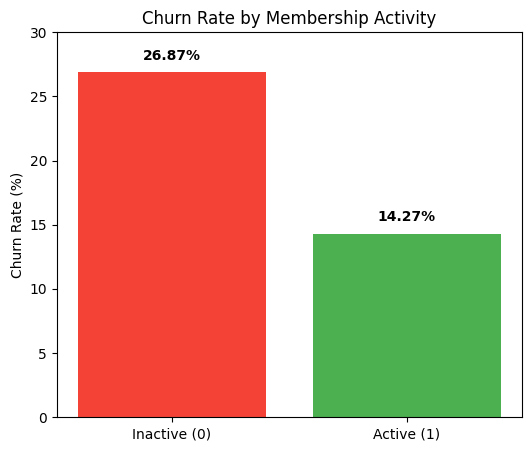

In [101]:
import matplotlib.pyplot as plt

# Data
members = ['Inactive (0)', 'Active (1)']
churn_rate = [26.87, 14.27]

# Plot
plt.figure(figsize=(6,5))
plt.bar(members, churn_rate, color=['#F44336','#4CAF50'])
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Membership Activity')
plt.ylim(0, 30)
for i, v in enumerate(churn_rate):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')
plt.show()

Interpretation

Inactive customers are twice as likely to leave.


# Analysis Findings

The data reveals that customer churn is strongly influenced by geography, complaints, and account activity:

## Geography:

Customers in Germany have the highest churn rate (~32.44%), compared to France (~16.17%) and Spain (~16.67%).

This indicates regional differences in customer satisfaction or banking service effectiveness. Factors such as local competition, branch availability, or service quality may contribute to higher churn in Germany.

## Complaints:

Customers who lodged complaints are significantly more likely to leave the bank.

This underscores that service experience and responsiveness are key drivers of customer retention. Unresolved complaints directly correlate with churn behavior.

### Account Activity:

Inactive members show a much higher churn rate (~26.87%) than active members (~14.27%).

This suggests that engagement with banking products and services reduces the likelihood of churn. Customers who do not regularly use their accounts are at greater risk of leaving.

# Recommendations

Based on these findings, the bank can implement the following strategies to reduce churn:

Targeted Regional Strategies:

Investigate the reasons behind Germany’s high churn rate. Consider enhancing customer service, offering tailored promotions, or expanding branch/online accessibility in that region.

Complaint Management:

Establish a proactive complaint resolution system.

Track and respond to complaints promptly and consider offering compensatory incentives for resolved issues.

Use feedback from complaints to identify recurring service problems and improve processes.

Increase Customer Engagement:

Encourage inactive customers to engage more with banking services through personalized campaigns, loyalty programs, or digital banking tutorials.

Offer incentives for regular usage, such as cashback rewards or interest benefits for active account holders.

Predictive Churn Monitoring:

Implement a churn prediction model using customer activity, complaints, and demographic data to identify high-risk customers early.

Reach out proactively to these customers with targeted retention offers.